
# Evaluasi Submission / Output Notebook yang Lebih Lengkap

Notebook ini adalah versi yang ditingkatkan dari evaluator sebelumnya.

Tujuan upgrade ini:

1. **Tidak cuma menghitung AW-MAE total**, tapi juga menampilkan metrik diagnostik lain.
2. **Lebih tahan error**, jadi kalau ada file yang bermasalah notebook tidak langsung berhenti.
3. Bisa dipakai untuk **membandingkan banyak submission/notebook sekaligus**.
4. Menyediakan **breakdown per grup** seperti tournament, gender, atau tahun jika kolomnya tersedia di ground truth.
5. Menampilkan **kasus-kasus error terburuk** supaya lebih mudah tahu kelemahan model.

Struktur evaluasi di notebook ini:

- leaderboard utama semua file submission
- sanity check file prediksi
- metrik detail per submission
- breakdown per grup
- worst-case rows
- perbandingan submission terhadap model referensi / model terbaik


In [9]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)


## Konfigurasi

Silakan sesuaikan bagian ini dengan struktur foldermu.

Update versi ini:

- `GT_PATH` sekarang diarahkan ke **`test_with_groundtruth.csv`**, bukan lagi `ground_truth_bersih.csv`.
- Karena `test_with_groundtruth.csv` punya kolom `tournament`, evaluator bisa menghitung **bobot turnamen**.
- Skor utama `awmae` / `best_awmae` sekarang memakai:

  `np.average(official_loss, weights=tournament_weight)`

Beberapa catatan:

- Kalau file `test_with_groundtruth.csv` ada di folder lain, cukup ubah daftar `GROUND_TRUTH_CANDIDATES`.
- `MANUAL_SUBMISSION_FILES` berisi daftar file prediksi yang ingin dievaluasi.
- Kalau mau otomatis mencari file `.csv`, aktifkan `USE_AUTO_DISCOVERY = True`.
- `EVAL_MODES` dibuat lebih lengkap:
  - `original_cast`: perilaku lama, mirip notebook awal (`astype(int)`).
  - `round_clip`: prediksi dibulatkan ke integer terdekat lalu di-clip minimal 0.
- `PRIMARY_MODE` adalah mode utama yang dipakai untuk breakdown detail dan worst cases.

In [10]:
# ============================================
# Ground Truth Path
# ============================================
# Versi terbaru memakai test_with_groundtruth.csv agar kolom tournament ikut terbaca
# dan bobot turnamen bisa dihitung.
#
# Urutan pencarian:
# 1) ../dataset/test_with_groundtruth.csv  -> cocok kalau notebook ada di folder notebook/
# 2) ../data/test_with_groundtruth.csv     -> alternatif umum
# 3) ./test_with_groundtruth.csv           -> cocok kalau file ada satu folder dengan notebook
# 4) /mnt/data/test_with_groundtruth.csv   -> cocok untuk file upload di ChatGPT/sandbox
GROUND_TRUTH_CANDIDATES = [
    Path("data/test_with_groundtruth.csv"),
    Path("data/test_with_groundtruth.csv"),

]

def first_existing_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    # Kalau belum ada yang ditemukan, pakai kandidat pertama supaya error message tetap jelas.
    return Path(candidates[0])

GT_PATH = first_existing_path(GROUND_TRUTH_CANDIDATES)
print("GT_PATH yang dipakai:", GT_PATH)

MANUAL_SUBMISSION_FILES = [
    "submission_exp12l_l4_exp39_plus_gd_patch_cap0025.csv"
]

USE_AUTO_DISCOVERY = False
SEARCH_DIRS = [Path("."), Path("../dump")]
AUTO_DISCOVERY_PATTERNS = ["*.csv"]
AUTO_EXCLUDE_KEYWORDS = ["ground_truth", "sample_submission", "leaderboard", "evaluation"]

EVAL_MODES = ("original_cast", "round_clip")
PRIMARY_MODE = "round_clip"
TOP_N_LEADERBOARD = 100
TOP_N_WORST_CASES = 10000
OUTPUT_DIR = Path("./evaluation_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


GT_PATH yang dipakai: data\test_with_groundtruth.csv



## Helper function evaluasi

Bagian ini berisi:

- fungsi bobot tournament
- perhitungan official loss
- validasi file
- merge GT vs prediction
- summary evaluasi yang lebih detail


In [11]:

# =========================
# 1) Tournament Weights
# =========================
def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    if "friendly" in t:
        return 0.96
    return 1.20


# =========================
# 2) Loss Constants
# =========================
EXACT_PENALTY = 0.30
OUTCOME_PENALTY = 0.25
GD_PENALTY = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER = 1.50


# =========================
# 3) Core helpers
# =========================
def _outcome(a: int, b: int) -> int:
    if a > b:
        return 1
    if a < b:
        return -1
    return 0


def official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred):
    y_team_true = np.asarray(y_team_true).astype(int)
    y_opp_true = np.asarray(y_opp_true).astype(int)
    y_team_pred = np.asarray(y_team_pred).astype(int)
    y_opp_pred = np.asarray(y_opp_pred).astype(int)

    base_mae = (
        np.abs(y_team_true - y_team_pred) +
        np.abs(y_opp_true - y_opp_pred)
    ) / 2.0

    exact_hit = (y_team_true == y_team_pred) & (y_opp_true == y_opp_pred)
    true_outcome = np.vectorize(_outcome)(y_team_true, y_opp_true)
    pred_outcome = np.vectorize(_outcome)(y_team_pred, y_opp_pred)
    outcome_hit = (true_outcome == pred_outcome)
    gd_hit = ((y_team_true - y_opp_true) == (y_team_pred - y_opp_pred))

    penalty = (
        (~exact_hit).astype(float) * EXACT_PENALTY +
        (~outcome_hit).astype(float) * OUTCOME_PENALTY +
        (~gd_hit).astype(float) * GD_PENALTY
    )

    raw_error = base_mae + penalty
    raw_error = np.where(outcome_hit, raw_error, raw_error * WRONG_OUTCOME_MULTIPLIER)

    return raw_error ** NONLINEAR_POWER


def awmae_score(y_team_true, y_opp_true, y_team_pred, y_opp_pred, weights=None) -> float:
    losses = official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred)
    if weights is None:
        weights = np.ones(len(losses), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    return float(np.average(losses, weights=weights))


def ensure_required_columns(df: pd.DataFrame, required_cols, df_name: str):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} tidak memiliki kolom wajib: {missing}. Kolom yang tersedia: {list(df.columns)}")


def read_gt(gt_path):
    gt_path = Path(gt_path)
    if not gt_path.exists():
        raise FileNotFoundError(
            f"Ground truth tidak ditemukan: {gt_path}\n"
            "Pastikan test_with_groundtruth.csv sudah diletakkan di salah satu path pada GROUND_TRUTH_CANDIDATES."
        )

    gt = pd.read_csv(gt_path)

    # Biar aman kalau suatu file memakai id kecil.
    if "Id" not in gt.columns and "id" in gt.columns:
        gt = gt.rename(columns={"id": "Id"})

    ensure_required_columns(gt, ["Id", "team_goals", "opp_goals"], "Ground truth")

    if "tournament" not in gt.columns:
        print(
            "WARNING: kolom 'tournament' tidak ditemukan di ground truth. "
            "AW-MAE tetap bisa dihitung, tapi bobot turnamen akan dianggap 1.0 semua."
        )

    if gt["Id"].duplicated().any():
        dup = gt.loc[gt["Id"].duplicated(), "Id"].tolist()[:10]
        raise ValueError(f"Ground truth memiliki Id duplikat. Contoh: {dup}")

    gt = gt.copy()
    gt["team_goals"] = pd.to_numeric(gt["team_goals"], errors="raise")
    gt["opp_goals"] = pd.to_numeric(gt["opp_goals"], errors="raise")
    return gt


def read_pred(pred_path):
    pred_path = Path(pred_path)
    if not pred_path.exists():
        raise FileNotFoundError(f"Prediction file tidak ditemukan: {pred_path}")

    pred = pd.read_csv(pred_path)
    ensure_required_columns(pred, ["Id", "team_goals", "opp_goals"], f"Prediction file: {pred_path.name}")
    return pred


def discover_submission_files(search_dirs, patterns=("*.csv",), exclude_keywords=None):
    files = []
    exclude_keywords = exclude_keywords or []
    for base_dir in search_dirs:
        base_dir = Path(base_dir)
        if not base_dir.exists():
            continue
        for pattern in patterns:
            for p in base_dir.rglob(pattern):
                name_lower = p.name.lower()
                if any(k.lower() in name_lower for k in exclude_keywords):
                    continue
                files.append(p)
    files = sorted(set(files))
    return files


def collect_submission_paths(manual_files=None, use_auto=False, search_dirs=None, patterns=("*.csv",), exclude_keywords=None):
    paths = []
    for item in manual_files or []:
        paths.append(Path(item))
    if use_auto:
        paths.extend(discover_submission_files(search_dirs or [], patterns=patterns, exclude_keywords=exclude_keywords))

    # unique sambil menjaga urutan
    seen = set()
    final_paths = []
    for p in paths:
        p_resolved = Path(p)
        if str(p_resolved) not in seen:
            seen.add(str(p_resolved))
            final_paths.append(p_resolved)
    return final_paths


def sanitize_pred_numeric(pred: pd.DataFrame) -> pd.DataFrame:
    out = pred.copy()
    out["team_goals_raw"] = pd.to_numeric(out["team_goals"], errors="coerce")
    out["opp_goals_raw"] = pd.to_numeric(out["opp_goals"], errors="coerce")

    if out[["team_goals_raw", "opp_goals_raw"]].isna().any().any():
        bad_rows = out[out[["team_goals_raw", "opp_goals_raw"]].isna().any(axis=1)].head(5)
        raise ValueError(
            "Ada nilai prediksi yang tidak bisa diubah menjadi numerik. "
            f"Contoh baris bermasalah:\n{bad_rows}"
        )
    return out


def make_eval_predictions(pred: pd.DataFrame, mode: str) -> pd.DataFrame:
    out = sanitize_pred_numeric(pred)

    if mode == "original_cast":
        out["team_goals_eval"] = out["team_goals_raw"].astype(int)
        out["opp_goals_eval"] = out["opp_goals_raw"].astype(int)
    elif mode == "round_clip":
        out["team_goals_eval"] = np.clip(np.rint(out["team_goals_raw"]), 0, None).astype(int)
        out["opp_goals_eval"] = np.clip(np.rint(out["opp_goals_raw"]), 0, None).astype(int)
    else:
        raise ValueError(f"Mode evaluasi tidak dikenal: {mode}")

    return out


def build_row_level_detail(gt: pd.DataFrame, pred: pd.DataFrame, mode: str) -> pd.DataFrame:
    pred_eval = make_eval_predictions(pred, mode=mode)

    df = gt.merge(
        pred_eval[["Id", "team_goals_raw", "opp_goals_raw", "team_goals_eval", "opp_goals_eval"]],
        on="Id",
        how="left"
    ).copy()

    df["missing_prediction"] = df[["team_goals_eval", "opp_goals_eval"]].isna().any(axis=1)

    if df["missing_prediction"].any():
        missing_ids = df.loc[df["missing_prediction"], "Id"].tolist()[:10]
        raise ValueError(f"Ada Id dari ground truth yang tidak ditemukan di prediction file. Contoh: {missing_ids}")

    df["team_goals_true"] = pd.to_numeric(df["team_goals"], errors="raise").astype(int)
    df["opp_goals_true"] = pd.to_numeric(df["opp_goals"], errors="raise").astype(int)
    df["team_goals_pred"] = df["team_goals_eval"].astype(int)
    df["opp_goals_pred"] = df["opp_goals_eval"].astype(int)

    df["team_abs_err"] = np.abs(df["team_goals_true"] - df["team_goals_pred"])
    df["opp_abs_err"] = np.abs(df["opp_goals_true"] - df["opp_goals_pred"])
    df["base_mae"] = (df["team_abs_err"] + df["opp_abs_err"]) / 2.0

    df["true_outcome"] = np.vectorize(_outcome)(df["team_goals_true"], df["opp_goals_true"])
    df["pred_outcome"] = np.vectorize(_outcome)(df["team_goals_pred"], df["opp_goals_pred"])

    df["exact_hit"] = (
        (df["team_goals_true"] == df["team_goals_pred"]) &
        (df["opp_goals_true"] == df["opp_goals_pred"])
    )
    df["outcome_hit"] = df["true_outcome"] == df["pred_outcome"]
    df["gd_hit"] = (
        (df["team_goals_true"] - df["opp_goals_true"]) ==
        (df["team_goals_pred"] - df["opp_goals_pred"])
    )

    df["penalty_exact"] = (~df["exact_hit"]).astype(float) * EXACT_PENALTY
    df["penalty_outcome"] = (~df["outcome_hit"]).astype(float) * OUTCOME_PENALTY
    df["penalty_gd"] = (~df["gd_hit"]).astype(float) * GD_PENALTY
    df["penalty_total"] = df[["penalty_exact", "penalty_outcome", "penalty_gd"]].sum(axis=1)

    df["raw_error_before_multiplier"] = df["base_mae"] + df["penalty_total"]
    df["wrong_outcome_multiplier"] = np.where(df["outcome_hit"], 1.0, WRONG_OUTCOME_MULTIPLIER)
    df["raw_error_after_multiplier"] = df["raw_error_before_multiplier"] * df["wrong_outcome_multiplier"]
    df["official_loss"] = df["raw_error_after_multiplier"] ** NONLINEAR_POWER

    if "tournament" in df.columns:
        df["tournament_weight"] = df["tournament"].apply(get_tournament_weight)
    else:
        df["tournament_weight"] = 1.0

    df["weighted_official_loss"] = df["official_loss"] * df["tournament_weight"]
    df["team_bias"] = df["team_goals_pred"] - df["team_goals_true"]
    df["opp_bias"] = df["opp_goals_pred"] - df["opp_goals_true"]
    df["total_goals_true"] = df["team_goals_true"] + df["opp_goals_true"]
    df["total_goals_pred"] = df["team_goals_pred"] + df["opp_goals_pred"]
    df["total_goals_abs_err"] = np.abs(df["total_goals_true"] - df["total_goals_pred"])
    df["goal_diff_true"] = df["team_goals_true"] - df["opp_goals_true"]
    df["goal_diff_pred"] = df["team_goals_pred"] - df["opp_goals_pred"]
    df["goal_diff_abs_err"] = np.abs(df["goal_diff_true"] - df["goal_diff_pred"])

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["year"] = df["date"].dt.year

    return df


def summarize_detail_df(df: pd.DataFrame, pred_raw: pd.DataFrame, pred_path: Path, mode: str) -> dict:
    gt_ids = set(df["Id"])
    pred_ids = set(pred_raw["Id"])

    duplicate_pred_ids = int(pred_raw["Id"].duplicated().sum())
    missing_in_pred = len(gt_ids - pred_ids)
    extra_in_pred = len(pred_ids - gt_ids)

    raw_numeric = sanitize_pred_numeric(pred_raw)
    summary = {
        "file": str(pred_path),
        "file_name": pred_path.name,
        "stem": pred_path.stem,
        "mode": mode,
        "n_gt": int(len(df)),
        "n_pred_rows": int(len(pred_raw)),
        "n_unique_pred_ids": int(pred_raw["Id"].nunique()),
        "duplicate_pred_ids": duplicate_pred_ids,
        "missing_in_pred": int(missing_in_pred),
        "extra_in_pred": int(extra_in_pred),
        "coverage_ratio": float(len(gt_ids & pred_ids) / max(len(gt_ids), 1)),
        "negative_team_pred_raw": int((raw_numeric["team_goals_raw"] < 0).sum()),
        "negative_opp_pred_raw": int((raw_numeric["opp_goals_raw"] < 0).sum()),
        "team_pred_raw_min": float(raw_numeric["team_goals_raw"].min()),
        "team_pred_raw_max": float(raw_numeric["team_goals_raw"].max()),
        "opp_pred_raw_min": float(raw_numeric["opp_goals_raw"].min()),
        "opp_pred_raw_max": float(raw_numeric["opp_goals_raw"].max()),
        "awmae": float(np.average(df["official_loss"], weights=df["tournament_weight"])),
        "awmae_unweighted": float(df["official_loss"].mean()),
        "mae_base": float(df["base_mae"].mean()),
        "mean_official_loss_unweighted": float(df["official_loss"].mean()),
        "uses_tournament_weight": bool("tournament" in df.columns),
        "tournament_weight_mean": float(df["tournament_weight"].mean()),
        "tournament_weight_min": float(df["tournament_weight"].min()),
        "tournament_weight_max": float(df["tournament_weight"].max()),
        "weight_sum": float(df["tournament_weight"].sum()),
        "exact_rate": float(df["exact_hit"].mean()),
        "outcome_rate": float(df["outcome_hit"].mean()),
        "gd_rate": float(df["gd_hit"].mean()),
        "avg_penalty_exact": float(df["penalty_exact"].mean()),
        "avg_penalty_outcome": float(df["penalty_outcome"].mean()),
        "avg_penalty_gd": float(df["penalty_gd"].mean()),
        "avg_penalty_total": float(df["penalty_total"].mean()),
        "team_bias_mean": float(df["team_bias"].mean()),
        "opp_bias_mean": float(df["opp_bias"].mean()),
        "team_abs_err_mean": float(df["team_abs_err"].mean()),
        "opp_abs_err_mean": float(df["opp_abs_err"].mean()),
        "total_goals_abs_err_mean": float(df["total_goals_abs_err"].mean()),
        "goal_diff_abs_err_mean": float(df["goal_diff_abs_err"].mean()),
    }
    return summary


def evaluate_submission_detailed(gt_path, pred_path, eval_modes=("original_cast", "round_clip")):
    gt = read_gt(gt_path)
    pred = read_pred(pred_path)

    if pred["Id"].duplicated().any():
        dup_ids = pred.loc[pred["Id"].duplicated(), "Id"].astype(str).tolist()[:10]
        raise ValueError(f"Prediction file memiliki Id duplikat. Contoh: {dup_ids}")

    mode_summaries = []
    mode_details = {}

    for mode in eval_modes:
        detail_df = build_row_level_detail(gt=gt, pred=pred, mode=mode)
        summary = summarize_detail_df(detail_df, pred_raw=pred, pred_path=Path(pred_path), mode=mode)
        mode_summaries.append(summary)
        mode_details[mode] = detail_df

    summary_df = pd.DataFrame(mode_summaries).sort_values("awmae", ascending=True).reset_index(drop=True)
    best_mode = summary_df.loc[0, "mode"]

    combined = {
        "file": str(pred_path),
        "file_name": Path(pred_path).name,
        "stem": Path(pred_path).stem,
        "best_mode": best_mode,
        "best_awmae": float(summary_df.loc[0, "awmae"]),
    }

    for _, row in summary_df.iterrows():
        prefix = row["mode"]
        for col, val in row.items():
            if col in {"file", "file_name", "stem", "mode"}:
                continue
            combined[f"{prefix}__{col}"] = val

    best_df = mode_details[best_mode].copy()
    return combined, summary_df, mode_details, best_df


def safe_evaluate_submission(gt_path, pred_path, eval_modes=("original_cast", "round_clip")):
    try:
        combined, summary_df, mode_details, best_df = evaluate_submission_detailed(
            gt_path=gt_path,
            pred_path=pred_path,
            eval_modes=eval_modes,
        )
        combined["status"] = "ok"
        combined["error"] = None
        return combined, summary_df, mode_details, best_df
    except Exception as e:
        return {
            "file": str(pred_path),
            "file_name": Path(pred_path).name,
            "stem": Path(pred_path).stem,
            "best_mode": None,
            "best_awmae": np.nan,
            "status": "error",
            "error": str(e),
        }, None, None, None


def group_breakdown(detail_df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    if group_col not in detail_df.columns:
        return pd.DataFrame()

    tmp = detail_df.copy()
    tmp[group_col] = tmp[group_col].fillna("<NA>")

    rows = []
    for key, part in tmp.groupby(group_col, dropna=False):
        rows.append({
            group_col: key,
            "n": int(len(part)),
            "awmae": float(np.average(part["official_loss"], weights=part["tournament_weight"])),
            "awmae_unweighted": float(part["official_loss"].mean()),
            "mean_tournament_weight": float(part["tournament_weight"].mean()),
            "mae_base": float(part["base_mae"].mean()),
            "exact_rate": float(part["exact_hit"].mean()),
            "outcome_rate": float(part["outcome_hit"].mean()),
            "gd_rate": float(part["gd_hit"].mean()),
            "team_bias_mean": float(part["team_bias"].mean()),
            "opp_bias_mean": float(part["opp_bias"].mean()),
            "avg_penalty_total": float(part["penalty_total"].mean()),
        })

    out = pd.DataFrame(rows).sort_values(["awmae", "n"], ascending=[True, False]).reset_index(drop=True)
    return out


def make_reference_comparison(details_store: dict, reference_file: str) -> pd.DataFrame:
    if reference_file not in details_store:
        return pd.DataFrame()

    ref_df = details_store[reference_file]["best_df"][["Id", "official_loss"]].rename(columns={"official_loss": "ref_loss"})
    rows = []
    for file_key, payload in details_store.items():
        cand = payload["best_df"][["Id", "official_loss"]].rename(columns={"official_loss": "cand_loss"})
        merged = ref_df.merge(cand, on="Id", how="inner")
        rows.append({
            "file": file_key,
            "avg_delta_vs_reference": float((merged["cand_loss"] - merged["ref_loss"]).mean()),
            "row_better_than_reference_rate": float((merged["cand_loss"] < merged["ref_loss"]).mean()),
            "row_equal_to_reference_rate": float((merged["cand_loss"] == merged["ref_loss"]).mean()),
        })
    out = pd.DataFrame(rows).sort_values("avg_delta_vs_reference", ascending=True).reset_index(drop=True)
    return out


## Sanity check ground truth dan bobot turnamen

Cell ini memastikan evaluator benar-benar membaca `test_with_groundtruth.csv`.

Yang perlu dicek:

- kolom `tournament` harus ada
- `tournament_weight` tidak semuanya 1.0
- jumlah row harus sama dengan jumlah row test/submission

In [12]:
gt_check = read_gt(GT_PATH).copy()

print("Ground truth path:", GT_PATH)
print("Jumlah row GT:", len(gt_check))
print("Kolom GT:", list(gt_check.columns))

if "tournament" in gt_check.columns:
    gt_check["tournament_weight"] = gt_check["tournament"].apply(get_tournament_weight)

    print("\nKolom tournament ditemukan ✅")
    print("Jumlah tournament unik:", gt_check["tournament"].nunique(dropna=False))
    print("Rata-rata bobot:", round(gt_check["tournament_weight"].mean(), 6))
    print("Bobot minimum:", gt_check["tournament_weight"].min())
    print("Bobot maksimum:", gt_check["tournament_weight"].max())

    print("\nDistribusi bobot turnamen:")
    display(
        gt_check["tournament_weight"]
        .value_counts()
        .sort_index()
        .rename_axis("tournament_weight")
        .reset_index(name="n_rows")
    )

    print("\nTop tournament berdasarkan jumlah row:")
    display(
        gt_check.groupby(["tournament", "tournament_weight"], dropna=False)
        .size()
        .reset_index(name="n_rows")
        .sort_values("n_rows", ascending=False)
        .head(20)
    )
else:
    print("\nWARNING: kolom tournament tidak ditemukan ❌")
    print("Skor AW-MAE akan sama seperti evaluasi lama karena semua bobot dianggap 1.0.")

Ground truth path: data\test_with_groundtruth.csv
Jumlah row GT: 42422
Kolom GT: ['Id', 'match_id', 'date', 'gender', 'team', 'opponent', 'is_home', 'neutral', 'tournament', 'venue_country', 'confederation_team', 'confederation_opp', 'population_team', 'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp', 'altitude_venue', 'distance_travel_team', 'distance_travel_opp', 'temperature_venue', 'team_goals', 'opp_goals']

Kolom tournament ditemukan ✅
Jumlah tournament unik: 167
Rata-rata bobot: 1.32323
Bobot minimum: 0.96
Bobot maksimum: 2.0

Distribusi bobot turnamen:


,tournament_weight,n_rows
0,0.96,10998
1,1.20,21268
2,1.80,1288
3,2.00,8868



Top tournament berdasarkan jumlah row:


,tournament,tournament_weight,n_rows
81,Friendly,0.96,10940
78,FIFA World Cup qualification,2.00,8148
148,UEFA Euro qualification,1.20,3222
16,African Cup of Nations qualification,1.20,2160
149,UEFA Nations League,1.20,1952
15,African Cup of Nations,1.20,844
41,CONCACAF Nations League,1.20,844
2,AFC Asian Cup qualification,1.80,788
77,FIFA World Cup,2.00,720
147,UEFA Euro,1.20,604



## Jalankan evaluasi semua file

Cell ini akan:

- mengumpulkan file prediksi
- mengevaluasi satu per satu
- menyimpan hasil ringkas dan detail
- tetap lanjut walaupun ada file yang error


In [13]:

submission_paths = collect_submission_paths(
    manual_files=MANUAL_SUBMISSION_FILES,
    use_auto=USE_AUTO_DISCOVERY,
    search_dirs=SEARCH_DIRS,
    patterns=AUTO_DISCOVERY_PATTERNS,
    exclude_keywords=AUTO_EXCLUDE_KEYWORDS,
)

print(f"Jumlah file yang akan dicek: {len(submission_paths)}")
for p in submission_paths:
    print("-", p)

summary_rows = []
mode_summary_store = {}
details_store = {}

for pred_path in submission_paths:
    combined, summary_df, mode_details, best_df = safe_evaluate_submission(
        gt_path=GT_PATH,
        pred_path=pred_path,
        eval_modes=EVAL_MODES,
    )
    summary_rows.append(combined)

    if combined.get("status") == "ok":
        mode_summary_store[str(pred_path)] = summary_df
        details_store[str(pred_path)] = {
            "mode_summary_df": summary_df,
            "mode_details": mode_details,
            "best_df": best_df,
            "best_mode": combined["best_mode"],
            "best_awmae": combined["best_awmae"],
        }

leaderboard_all = pd.DataFrame(summary_rows)
leaderboard_ok = leaderboard_all[leaderboard_all["status"] == "ok"].copy()
leaderboard_err = leaderboard_all[leaderboard_all["status"] != "ok"].copy()

if not leaderboard_ok.empty:
    leaderboard_ok = leaderboard_ok.sort_values("best_awmae", ascending=True).reset_index(drop=True)

leaderboard_all.to_csv(OUTPUT_DIR / "leaderboard_all.csv", index=False)
if not leaderboard_ok.empty:
    leaderboard_ok.to_csv(OUTPUT_DIR / "leaderboard_ok.csv", index=False)
if not leaderboard_err.empty:
    leaderboard_err.to_csv(OUTPUT_DIR / "leaderboard_error.csv", index=False)


Jumlah file yang akan dicek: 1
- submission_exp12l_l4_exp39_plus_gd_patch_cap0025.csv



## Leaderboard utama

Kolom yang paling penting untuk dibaca:

- `best_awmae`: skor terbaik file tersebut dari mode evaluasi yang dicoba
- `best_mode`: mode evaluasi terbaiknya
- `round_clip__awmae`: biasanya ini yang lebih aman kalau ada output float
- `exact_rate`: seberapa sering skor tepat persis
- `outcome_rate`: seberapa sering win/draw/loss benar
- `gd_rate`: seberapa sering selisih gol benar
- `team_bias_mean` dan `opp_bias_mean`: apakah model cenderung overpredict atau underpredict


In [14]:

if leaderboard_ok.empty:
    print("Belum ada file yang berhasil dievaluasi. Cek GT path dan file submission.")
else:
    important_cols = [
        "file_name",
        "best_mode",
        "best_awmae",
        "original_cast__awmae",
        "round_clip__awmae",
        "round_clip__awmae_unweighted",
        "round_clip__uses_tournament_weight",
        "round_clip__tournament_weight_mean",
        "round_clip__tournament_weight_min",
        "round_clip__tournament_weight_max",
        "round_clip__mae_base",
        "round_clip__exact_rate",
        "round_clip__outcome_rate",
        "round_clip__gd_rate",
        "round_clip__team_bias_mean",
        "round_clip__opp_bias_mean",
        "round_clip__duplicate_pred_ids",
        "round_clip__missing_in_pred",
        "round_clip__extra_in_pred",
        "status",
    ]
    important_cols = [c for c in important_cols if c in leaderboard_ok.columns]
    display(leaderboard_ok[important_cols].head(TOP_N_LEADERBOARD))

if not leaderboard_err.empty:
    print("\nFile yang error saat evaluasi:")
    display(leaderboard_err[["file_name", "error"]])

,file_name,best_mode,best_awmae,original_cast__awmae,round_clip__awmae,round_clip__awmae_unweighted,round_clip__uses_tournament_weight,round_clip__tournament_weight_mean,round_clip__tournament_weight_min,round_clip__tournament_weight_max,round_clip__mae_base,round_clip__exact_rate,round_clip__outcome_rate,round_clip__gd_rate,round_clip__team_bias_mean,round_clip__opp_bias_mean,round_clip__duplicate_pred_ids,round_clip__missing_in_pred,round_clip__extra_in_pred,status
0,submission_exp12l_l4_exp39_plus_gd_patch_cap0025.csv,original_cast,2.95914,2.95914,2.95914,2.978249,True,1.32323,0.96,2.0,1.028311,0.107444,0.584272,0.228372,-0.243105,-0.243105,0,0,0,ok


In [15]:
leaderboard_ok[leaderboard_ok['best_awmae'] < 3.05]['file'].tolist()

['submission_exp12l_l4_exp39_plus_gd_patch_cap0025.csv']


## Visualisasi leaderboard


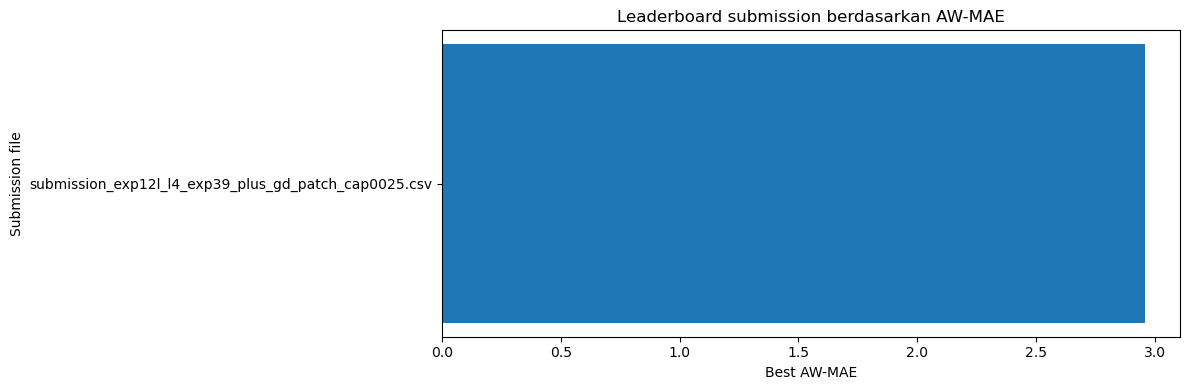

In [16]:

if not leaderboard_ok.empty:
    top_plot = leaderboard_ok.head(min(TOP_N_LEADERBOARD, len(leaderboard_ok))).copy()
    plt.figure(figsize=(12, max(4, 0.45 * len(top_plot))))
    plt.barh(top_plot["file_name"], top_plot["best_awmae"])
    plt.gca().invert_yaxis()
    plt.xlabel("Best AW-MAE")
    plt.ylabel("Submission file")
    plt.title("Leaderboard submission berdasarkan AW-MAE")
    plt.tight_layout()
    plt.show()



## Lihat detail mode evaluasi per file

Cell ini berguna kalau kamu ingin tahu, untuk satu file tertentu, apakah `original_cast` atau `round_clip` lebih masuk akal.


In [17]:

if not leaderboard_ok.empty:
    selected_file = leaderboard_ok.loc[9, "file"]
    print("File yang sedang diinspeksi:", selected_file)
    display(mode_summary_store[selected_file])


KeyError: 9

In [ ]:
if not leaderboard_ok.empty:
    selected_file = leaderboard_ok.loc[0, "file"]
    print("File yang sedang diinspeksi:", selected_file)
    display(mode_summary_store[selected_file])

File yang sedang diinspeksi: DSC26045_BCC lagi bawa anak baru_Submission (1).csv


,file,file_name,stem,mode,n_gt,n_pred_rows,n_unique_pred_ids,duplicate_pred_ids,missing_in_pred,extra_in_pred,coverage_ratio,negative_team_pred_raw,negative_opp_pred_raw,team_pred_raw_min,team_pred_raw_max,opp_pred_raw_min,opp_pred_raw_max,awmae,awmae_unweighted,mae_base,mean_official_loss_unweighted,uses_tournament_weight,tournament_weight_mean,tournament_weight_min,tournament_weight_max,weight_sum,exact_rate,outcome_rate,gd_rate,avg_penalty_exact,avg_penalty_outcome,avg_penalty_gd,avg_penalty_total,team_bias_mean,opp_bias_mean,team_abs_err_mean,opp_abs_err_mean,total_goals_abs_err_mean,goal_diff_abs_err_mean
0,DSC26045_BCC lagi bawa anak baru_Submission (1).csv,DSC26045_BCC lagi bawa anak baru_Submission (1).csv,DSC26045_BCC lagi bawa anak baru_Submission (1),original_cast,42422,42422,42422,0,0,0,1.0,0,0,0.0,6.0,0.0,6.0,2.827012,2.858826,1.006294,2.858826,True,1.32323,0.96,2.0,56134.08,0.10867,0.610509,0.239781,0.267399,0.097373,0.114033,0.478805,-0.097567,-0.097992,1.006388,1.0062,1.572109,1.537127
1,DSC26045_BCC lagi bawa anak baru_Submission (1).csv,DSC26045_BCC lagi bawa anak baru_Submission (1).csv,DSC26045_BCC lagi bawa anak baru_Submission (1),round_clip,42422,42422,42422,0,0,0,1.0,0,0,0.0,6.0,0.0,6.0,2.827012,2.858826,1.006294,2.858826,True,1.32323,0.96,2.0,56134.08,0.10867,0.610509,0.239781,0.267399,0.097373,0.114033,0.478805,-0.097567,-0.097992,1.006388,1.0062,1.572109,1.537127



## Breakdown detail untuk model terbaik

Bagian ini membantu menjawab pertanyaan seperti:

- model paling jelek di tournament apa?
- apakah performa beda jauh antara gender tertentu?
- tahun mana yang paling sulit?


In [ ]:

if not leaderboard_ok.empty:
    best_file = leaderboard_ok.loc[0, "file"]
    best_payload = details_store[best_file]
    best_df = best_payload["best_df"].copy()

    print("Best file:", best_file)
    print("Best mode:", best_payload["best_mode"])
    print("Best AW-MAE:", round(best_payload["best_awmae"], 6))

    group_candidates = ["tournament", "gender", "year", "home_team", "away_team"]
    for col in group_candidates:
        breakdown = group_breakdown(best_df, col)
        if not breakdown.empty:
            print(f"\nBreakdown by {col}:")
            display(breakdown.head(20))
            breakdown.to_csv(OUTPUT_DIR / f"best_model_breakdown_by_{col}.csv", index=False)


Best file: DSC26045_BCC lagi bawa anak baru_Submission (1).csv
Best mode: original_cast
Best AW-MAE: 2.827012

Breakdown by tournament:


,tournament,n,awmae,awmae_unweighted,mean_tournament_weight,mae_base,exact_rate,outcome_rate,gd_rate,team_bias_mean,opp_bias_mean,avg_penalty_total
0,ConIFA Challenger Cup,2,0.000000,0.000000,1.2,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
1,Olympic qualifyication,4,0.925945,0.925945,1.2,0.500000,0.000000,1.000000,0.000000,0.500000,0.500000,0.450000
2,EAFF Championship qualification,10,1.184783,1.184783,1.2,0.400000,0.400000,0.800000,0.400000,0.000000,0.000000,0.320000
3,Jordan International Tournament,8,1.205782,1.205782,1.2,0.500000,0.250000,0.750000,0.500000,0.250000,0.250000,0.362500
4,Malta International Tournament,6,1.401752,1.401752,1.2,0.833333,0.333333,1.000000,0.666667,-0.166667,-0.166667,0.250000
5,Cup of Nations,24,1.511912,1.511912,1.2,0.625000,0.416667,0.833333,0.416667,-0.291667,-0.291667,0.304167
6,Hungary Heritage Cup,6,1.665990,1.665990,1.2,0.500000,0.333333,0.666667,0.333333,-0.166667,-0.166667,0.383333
7,Tri Nation Tournament,14,1.677689,1.677689,1.2,0.571429,0.285714,0.714286,0.428571,0.285714,0.285714,0.371429
8,Three Nations Cup,6,1.695643,1.695643,1.2,0.666667,0.000000,0.666667,0.000000,0.000000,0.000000,0.533333
9,VisitMalta Women's Trophy,8,1.708240,1.708240,1.2,0.750000,0.000000,0.750000,0.000000,0.250000,0.250000,0.512500



Breakdown by gender:


,gender,n,awmae,awmae_unweighted,mean_tournament_weight,mae_base,exact_rate,outcome_rate,gd_rate,team_bias_mean,opp_bias_mean,avg_penalty_total
0,M,28464,2.674245,2.705767,1.343272,0.925169,0.116779,0.575604,0.258888,-0.087198,-0.087268,0.482232
1,W,13958,3.153343,3.170955,1.282361,1.171729,0.092134,0.681688,0.200817,-0.118713,-0.119860,0.471815



Breakdown by year:


,year,n,awmae,awmae_unweighted,mean_tournament_weight,mae_base,exact_rate,outcome_rate,gd_rate,team_bias_mean,opp_bias_mean,avg_penalty_total
0,2026,566,2.561144,2.665408,1.396325,0.969965,0.102473,0.641343,0.257951,-0.132509,-0.128975,0.470230
1,2021,3084,2.660430,2.724894,1.541375,1.015240,0.108301,0.652399,0.253567,-0.145590,-0.145590,0.466375
2,2022,3162,2.707263,2.724299,1.287970,0.977230,0.115117,0.626186,0.247312,-0.044908,-0.046173,0.471822
3,2020,1134,2.707591,2.690322,1.183492,0.952381,0.114638,0.596120,0.243386,-0.051146,-0.051146,0.480071
4,2016,2576,2.722155,2.771667,1.306522,0.998835,0.106366,0.627717,0.254658,-0.105590,-0.106366,0.472962
5,2024,3634,2.771052,2.810927,1.270204,0.973308,0.106219,0.591359,0.242157,-0.003027,-0.002477,0.483971
6,2017,2602,2.804368,2.836314,1.421430,0.980400,0.118755,0.589931,0.256726,-0.086856,-0.088394,0.478382
7,2013,2446,2.818228,2.853549,1.453017,0.983851,0.100164,0.580131,0.231807,-0.136141,-0.136549,0.490147
8,2011,1532,2.834945,2.847754,1.309138,0.996736,0.110966,0.621410,0.233681,-0.132507,-0.132507,0.476305
9,2019,3452,2.850973,2.866600,1.258702,1.035197,0.106025,0.638470,0.224218,-0.127462,-0.127752,0.474942



## Worst-case rows dari model terbaik

Ini penting karena dari sini biasanya kita bisa tahu pola error terbesar, misalnya:

- pertandingan dengan skor besar
- pertandingan tertentu yang outcome-nya salah total
- turnamen tertentu yang sulit


In [ ]:

if not leaderboard_ok.empty:
    best_file = leaderboard_ok.loc[0, "file"]
    best_df = details_store[best_file]["best_df"].copy()

    cols_to_show = [
        "Id",
        "date",
        "tournament",
        "gender",
        "home_team",
        "away_team",
        "team_goals_true",
        "opp_goals_true",
        "team_goals_pred",
        "opp_goals_pred",
        "base_mae",
        "penalty_total",
        "official_loss",
        "exact_hit",
        "outcome_hit",
        "gd_hit",
        "team_bias",
        "opp_bias",
    ]
    cols_to_show = [c for c in cols_to_show if c in best_df.columns]

    worst_cases = best_df.sort_values("official_loss", ascending=False).head(TOP_N_WORST_CASES)
    display(worst_cases[cols_to_show])
    worst_cases[cols_to_show].to_csv(OUTPUT_DIR / "best_model_worst_cases.csv", index=False)


,Id,date,tournament,gender,team_goals_true,opp_goals_true,team_goals_pred,opp_goals_pred,base_mae,penalty_total,official_loss,exact_hit,outcome_hit,gd_hit,team_bias,opp_bias
2443,M035876_Provence,2012-06-05,Viva World Cup,M,18,0,1,2,9.5,0.7,59.846278,False,False,False,-17,2
2442,M035876_Darfur,2012-06-05,Viva World Cup,M,0,18,2,1,9.5,0.7,59.846278,False,False,False,2,-17
1551,M035568_Raetia,2012-01-14,Friendly,M,1,17,2,1,8.5,0.7,51.264725,False,False,False,1,-16
1550,M035568_Gozo,2012-01-14,Friendly,M,17,1,1,2,8.5,0.7,51.264725,False,False,False,-16,1
653,W004478_Iraq,2011-10-03,WAFF Championship,W,0,12,2,1,6.5,0.7,35.492422,False,False,False,2,-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31161,W009166_Nigeria,2023-02-18,Women's Revelations Cup,W,0,1,2,1,1.0,0.7,4.072023,False,False,False,2,0
31160,W009166_Colombia,2023-02-18,Women's Revelations Cup,W,1,0,1,2,1.0,0.7,4.072023,False,False,False,0,2
16257,M040911_Algeria,2017-09-02,FIFA World Cup qualification,M,1,3,1,1,1.0,0.7,4.072023,False,False,False,0,-2
16256,M040911_Zambia,2017-09-02,FIFA World Cup qualification,M,3,1,1,1,1.0,0.7,4.072023,False,False,False,-2,0



## Perbandingan terhadap model referensi / model terbaik

Interpretasi kolom:

- `avg_delta_vs_reference < 0`: rata-rata model ini lebih baik daripada referensi
- `row_better_than_reference_rate`: proporsi baris dimana loss model ini lebih kecil daripada referensi

Secara default, referensi yang dipakai adalah model terbaik di leaderboard.


In [ ]:

if not leaderboard_ok.empty:
    reference_file = leaderboard_ok.loc[0, "file"]
    comparison_df = make_reference_comparison(details_store, reference_file=reference_file)
    print("Reference file:", reference_file)
    display(comparison_df)
    comparison_df.to_csv(OUTPUT_DIR / "comparison_vs_reference.csv", index=False)


Reference file: DSC26045_BCC lagi bawa anak baru_Submission (1).csv


,file,avg_delta_vs_reference,row_better_than_reference_rate,row_equal_to_reference_rate
0,DSC26045_BCC lagi bawa anak baru_Submission (1).csv,0.000000,0.000000,1.000000
1,submission_exp39_SAFE_FINAL_scoreline_distribution_validation_only.csv,0.120004,0.217128,0.524798
2,submission_exp40_SAFE_FINAL_optuna_scoreline_calibration_validation_only.csv,0.125207,0.218165,0.524610
3,submission_exp38_SAFE_FINAL_segment_router_validation_only.csv,0.127867,0.215572,0.531917
4,submission_exp37_SAFE_best_by_validation_proxy_no_gt.csv,0.129121,0.216279,0.529372
5,submission_exp36_SAFE_high_risk_score_remap_validation_only.csv,0.131327,0.216656,0.528570
6,submission_exp30_repaired__exp25a_segment_decoder_direct.csv,0.135381,0.222998,0.521545
7,submission_exp26_exp25a_segment_decoder__mean_round.csv,0.135381,0.222998,0.521545
8,submission_exp30_repaired__exp26_exp25a_segment_decoder.csv,0.135381,0.222998,0.521545
9,submission_exp30_best_by_optional_gt_audit.csv,0.135381,0.222998,0.521545


In [ ]:
# ============================================
# TAMPILKAN DETAIL TRUE VS PREDICTION
# DIURUTKAN BERDASARKAN TRUE GOALS TERBESAR
# ============================================

from IPython.display import display

# GANTI variabel ini sesuai dataframe detail di notebook kamu
# contoh: df_detail, merged_df, eval_detail_df, dst.
df_view = worst_cases.copy()

# Kalau dataframe berisi banyak submission/file sekaligus,
# isi nama file yang ingin dilihat. Kalau tidak, biarkan None.
target_submission = 'submission_v10.csv'
# contoh:
# target_submission = "exp03_submission.csv"

if target_submission is not None:
    submission_col_candidates = ["submission_name", "file_name", "source_file", "notebook_name"]
    sub_col = next((c for c in submission_col_candidates if c in df_view.columns), None)
    if sub_col is not None:
        df_view = df_view[df_view[sub_col] == target_submission].copy()

# Cari nama kolom true/pred yang tersedia
true_team_col = next((c for c in ["team_goals_true", "true_team_goals", "team_goals_gt", "team_goals"] if c in df_view.columns), None)
true_opp_col  = next((c for c in ["opp_goals_true", "true_opp_goals", "opp_goals_gt", "opp_goals"] if c in df_view.columns), None)

pred_team_col = next((c for c in ["team_goals_pred", "pred_team_goals", "yhat_team_goals", "team_goals_prediction"] if c in df_view.columns), None)
pred_opp_col  = next((c for c in ["opp_goals_pred", "pred_opp_goals", "yhat_opp_goals", "opp_goals_prediction"] if c in df_view.columns), None)

if true_team_col is None or true_opp_col is None:
    raise ValueError("Kolom ground truth team/opp goals tidak ditemukan di dataframe detail.")

# Tambah total goal true dan pred kalau kolom pred tersedia
df_view["true_total_goals"] = df_view[true_team_col] + df_view[true_opp_col]

if pred_team_col is not None and pred_opp_col is not None:
    df_view["pred_total_goals"] = df_view[pred_team_col] + df_view[pred_opp_col]
    df_view["abs_err_team"] = (df_view[true_team_col] - df_view[pred_team_col]).abs()
    df_view["abs_err_opp"]  = (df_view[true_opp_col] - df_view[pred_opp_col]).abs()
    df_view["abs_err_total"] = df_view["abs_err_team"] + df_view["abs_err_opp"]

# Urutkan:
# 1. true_total_goals terbesar
# 2. true team_goals terbesar
# 3. true opp_goals terbesar
sort_cols = ["true_total_goals", true_team_col, true_opp_col]
ascending = [False, False, False]

# Tambahkan error sebagai tie-breaker kalau ada
if "abs_err_total" in df_view.columns:
    sort_cols.append("abs_err_total")
    ascending.append(False)

df_view = df_view.sort_values(by=sort_cols, ascending=ascending).reset_index(drop=True)

# Kolom yang ingin ditampilkan di depan
front_cols = [
    "Id", "match_id",
    true_team_col, true_opp_col, "true_total_goals",
    pred_team_col, pred_opp_col, "pred_total_goals",
    "abs_err_team", "abs_err_opp", "abs_err_total",
    "awmae_row", "base_mae", "exact_hit", "outcome_hit", "gd_hit",
    "tournament", "gender", "date"
]

front_cols = [c for c in front_cols if c is not None and c in df_view.columns]
other_cols = [c for c in df_view.columns if c not in front_cols]

display(df_view[front_cols + other_cols].head(50))

,Id,match_id,team_goals_true,opp_goals_true,true_total_goals,team_goals_pred,opp_goals_pred,pred_total_goals,abs_err_team,abs_err_opp,abs_err_total,base_mae,exact_hit,outcome_hit,gd_hit,tournament,gender,date,team,opponent,is_home,neutral,venue_country,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue,team_goals,opp_goals,team_goals_raw,opp_goals_raw,team_goals_eval,opp_goals_eval,missing_prediction,team_abs_err,opp_abs_err,true_outcome,pred_outcome,penalty_exact,penalty_outcome,penalty_gd,penalty_total,raw_error_before_multiplier,wrong_outcome_multiplier,raw_error_after_multiplier,official_loss,tournament_weight,weighted_official_loss,team_bias,opp_bias,total_goals_true,total_goals_pred,total_goals_abs_err,goal_diff_true,goal_diff_pred,goal_diff_abs_err,year
0,W005022_Jordan,W005022,21,0,21,3,1,4,18,1,19,9.5,False,True,False,AFC Asian Cup qualification,W,2013-06-07,Jordan,Kuwait,1,0,Jordan,AFC,AFC,9494246.0,3908743.0,4044.426869,49388.053380,745.0,0.000000,1212.215809,26.693250,21,0,3,1,3,1,False,18,1,1,1,0.3,0.00,0.15,0.45,9.95,1.0,9.95,31.385902,1.80,56.494624,-18,1,21,4,17,21,2,19,2013
1,W008680_Haiti,W008680,21,0,21,6,0,6,15,0,15,7.5,False,True,False,CONCACAF Championship qualification,W,2022-04-09,Haiti,British Virgin Islands,0,0,British Virgin Islands,CONCACAF,CONCACAF,11584996.0,31305.0,1272.367992,NaN,NaN,NaN,NaN,NaN,21,0,6,0,6,0,False,15,0,1,1,0.3,0.00,0.15,0.45,7.95,1.0,7.95,22.415617,1.20,26.898740,-15,0,21,6,15,21,6,15,2022
2,W005022_Kuwait,W005022,0,21,21,1,3,4,1,18,19,9.5,False,True,False,AFC Asian Cup qualification,W,2013-06-07,Kuwait,Jordan,0,0,Jordan,AFC,AFC,3908743.0,9494246.0,49388.053380,4044.426869,745.0,1212.215809,0.000000,26.693250,0,21,1,3,1,3,False,1,18,-1,-1,0.3,0.00,0.15,0.45,9.95,1.0,9.95,31.385902,1.80,56.494624,1,-18,21,4,17,-21,-2,19,2013
3,W008680_British Virgin Islands,W008680,0,21,21,0,6,6,0,15,15,7.5,False,True,False,CONCACAF Championship qualification,W,2022-04-09,British Virgin Islands,Haiti,1,0,British Virgin Islands,CONCACAF,CONCACAF,31305.0,11584996.0,NaN,1272.367992,NaN,NaN,NaN,NaN,0,21,0,6,0,6,False,0,15,-1,-1,0.3,0.00,0.15,0.45,7.95,1.0,7.95,22.415617,1.20,26.898740,0,-15,21,6,15,-21,-6,15,2022
4,M037746_Padania,M037746,20,0,20,2,1,3,18,1,19,9.5,False,True,False,CONIFA World Football Cup,M,2014-06-01,Padania,Darfur,0,1,Sweden,Unknown,Unknown,NaN,NaN,NaN,NaN,27.0,NaN,NaN,11.796964,20,0,2,1,2,1,False,18,1,1,1,0.3,0.00,0.15,0.45,9.95,1.0,9.95,31.385902,1.20,37.663083,-18,1,20,3,17,20,1,19,2014
5,W004468_Russia,W004468,20,0,20,3,1,4,17,1,18,9.0,False,True,False,UEFA Euro qualification,W,2011-09-21,Russia,Poland,0,0,Poland,UEFA,UEFA,143242599.0,38597353.0,NaN,13879.560985,169.0,2641.449325,0.000000,14.959172,20,0,3,1,3,1,False,17,1,1,1,0.3,0.00,0.15,0.45,9.45,1.0,9.45,29.050105,1.20,34.860127,-17,1,20,4,16,20,2,18,2011
6,W007252_Uzbekistan,W007252,20,0,20,4,0,4,16,0,16,8.0,False,True,False,CAFA Championship,W,2018-11-23,Uzbekistan,Afghanistan,1,0,Uzbekistan,AFC,AFC,33526656.0,38972230.0,1597.068337,485.668419,NaN,NaN,NaN,2.686283,20,0,4,0,4,0,False,16,0,1,1,0.3,0.00,0.15,0.45,8.45,1.0,8.45,24.563207,1.20,29.475848,-16,0,20,4,16,20,4,16,2018
7,W008483_England,W008483,20,0,20,6,0,6,14,0,14,7.0,False,True,False,FIFA World Cup qualification,W,2021-11-30,England,Latvia,1,0,England,UEFA,UEFA,NaN,1897052.0,NaN,17726.252935,NaN,NaN,NaN,NaN,20,0,6,0,6,0,False,14,0,1,1,0.3,0.00,0.15,0.45,7.45,1.0,7.45,20.334543,2.00,40.669085,-14,0,20,6,14,20,6,14,2021
8,M037746_Darfur,M037746,0,20,20,1,2,3,1,18,19,9.5,False,True,False,CONIFA World Football Cup,M,2014-06-01,Darfur,Padania,1,1,Sweden,Unknown,Unknown,NaN,NaN,NaN,NaN,27.0,NaN,NaN,11.796964,0,20,1,2,1,2,False,1,18,-1,-1,0.3,0.00,0.15,0.45,9.95,1.0,9.95,31.385902,1.20,37.663083,1,-18,20,3,17,-20,-1,19,2014
9,W004468_Poland,W004468,0,20,20,1,3,4,1,17,18,9.0,False,True,False,UEFA Euro qualification,W,2011-09-21,Poland,Russia,

In [ ]:
# ============================================
# HITUNG JUMLAH PREDIKSI DENGAN AW-MAE > 4
# DAN TAMPILKAN DETAIL PREDIKSINYA
# ============================================

from IPython.display import display

# GANTI ini dengan dataframe detail evaluasimu
# misalnya: merged_df, eval_detail_df, df_detail, dst.
df_view = worst_cases.copy()

# Cari kolom AW-MAE per baris
awmae_col = "base_mae"

if awmae_col is None:
    raise ValueError("Kolom AW-MAE per baris tidak ditemukan. Cek nama kolom di dataframe detail evaluasi.")

# Filter baris dengan AW-MAE > 4
bad_preds = df_view[df_view[awmae_col] > 1].copy()

# Tampilkan jumlahnya
print(f"Jumlah prediksi dengan {awmae_col} > 1: {len(bad_preds)}")

# Urutkan dari yang paling besar
bad_preds = bad_preds.sort_values(by=awmae_col, ascending=False).reset_index(drop=True)

# Cari nama kolom yang tersedia
true_team_col = next((c for c in ["team_goals_true", "true_team_goals", "team_goals_gt", "team_goals"] if c in bad_preds.columns), None)
true_opp_col  = next((c for c in ["opp_goals_true", "true_opp_goals", "opp_goals_gt", "opp_goals"] if c in bad_preds.columns), None)

pred_team_col = next((c for c in ["team_goals_pred", "pred_team_goals", "yhat_team_goals", "team_goals_prediction"] if c in bad_preds.columns), None)
pred_opp_col  = next((c for c in ["opp_goals_pred", "pred_opp_goals", "yhat_opp_goals", "opp_goals_prediction"] if c in bad_preds.columns), None)

# Kolom yang mau ditampilkan
cols_show = [
    "Id", "match_id", "date", "tournament", "gender",
    true_team_col, true_opp_col,
    pred_team_col, pred_opp_col,
    awmae_col,
    "base_mae", "exact_hit", "outcome_hit", "gd_hit"
]

cols_show = [c for c in cols_show if c is not None and c in bad_preds.columns]

display(bad_preds[cols_show])

Jumlah prediksi dengan base_mae > 1: 7553


,Id,match_id,date,tournament,gender,team_goals_true,opp_goals_true,team_goals_pred,opp_goals_pred,base_mae,base_mae,exact_hit,outcome_hit,gd_hit
0,M035876_Provence,M035876,2012-06-05,Viva World Cup,M,18,0,1,2,9.5,9.5,False,False,False
1,W005022_Jordan,W005022,2013-06-07,AFC Asian Cup qualification,W,21,0,3,1,9.5,9.5,False,True,False
2,M037746_Darfur,M037746,2014-06-01,CONIFA World Football Cup,M,0,20,1,2,9.5,9.5,False,True,False
3,M037746_Padania,M037746,2014-06-01,CONIFA World Football Cup,M,20,0,2,1,9.5,9.5,False,True,False
4,W005022_Kuwait,W005022,2013-06-07,AFC Asian Cup qualification,W,0,21,1,3,9.5,9.5,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7548,M036223_Venezuela,M036223,2012-09-11,FIFA World Cup qualification,M,2,0,1,2,1.5,1.5,False,False,False
7549,M036215_Lebanon,M036215,2012-09-11,FIFA World Cup qualification,M,1,0,0,2,1.5,1.5,False,False,False
7550,M036215_Iran,M036215,2012-09-11,FIFA World Cup qualification,M,0,1,2,0,1.5,1.5,False,False,False
7551,M036216_Liberia,M036216,2012-09-11,Friendly,M,2,0,0,1,1.5,1.5,False,False,False



## Ringkasan interpretasi

Checklist membaca hasil evaluasi:

1. **Lihat `best_awmae`** untuk ranking utama.
2. **Bandingkan `mae_base` vs `official_loss`**. Kalau `mae_base` tidak terlalu buruk tapi `official_loss` tinggi, biasanya masalah ada di outcome / goal difference / exact score penalty.
3. **Lihat `exact_rate`, `outcome_rate`, `gd_rate`** untuk tahu model kuat di aspek mana.
4. **Lihat bias**:
   - `team_bias_mean > 0` artinya cenderung overpredict gol tim
   - `team_bias_mean < 0` artinya cenderung underpredict gol tim
5. **Lihat breakdown per tournament / gender / year** untuk mencari domain yang masih lemah.
6. **Lihat worst cases** untuk menentukan eksperimen lanjutan.

Contoh ide tindak lanjut setelah evaluasi:

- kalau lemah di tournament tertentu → coba model/domain split per tournament
- kalau outcome sering salah → tambahkan objective yang lebih fokus ke direction win/draw/loss
- kalau exact rate rendah tapi outcome rate lumayan → mungkin post-processing scoreline perlu diperbaiki
- kalau bias gol terlalu tinggi/rendah → cek calibration atau clipping prediksi
